# Embedding Visualisation 

In [1]:
from pathlib import Path
import networkx as nx
import pandas as pd

FOLDER = Path('./asnr datasets')
assert FOLDER.exists(), f"Dataset folder not found: {FOLDER}"

asnr_graphs: dict[str, nx.Graph] = {}
for fp in FOLDER.glob('*.graphml'):
    asnr_graphs[fp.stem + '.graphml'] = nx.read_graphml(fp)

info_frame = pd.read_csv(FOLDER / 'Network_summary_masterfile.csv')

selected_classes = ['Mammalia', 'Insecta', 'Aves']
selected_interactions = [
    'physical_contact', 'social_projection_bipartite', 'spatial_proximity',
    'grooming', 'dominance', 'FE_mating',
]

filtered_df = (
    info_frame[
        info_frame['interaction_type'].isin(selected_interactions) &
        info_frame['class'].isin(selected_classes) &
        (info_frame['nodes'] > 5) &
        pd.notna(info_frame['avg.edge.strength'])
    ]
    .copy()
    .rename(columns={'class': 'network_class'})
    .reset_index(drop=True)
)

interaction_mapping = {c: i for i, c in enumerate(selected_interactions)}
bio_class_mapping   = {c: i for i, c in enumerate(selected_classes)}
filtered_df['interaction_map'] = filtered_df['interaction_type'].map(interaction_mapping)

bio_inv         = {v: k for k, v in bio_class_mapping.items()}
interaction_inv = {v: k for k, v in interaction_mapping.items()}
bio_names       = [bio_inv[i] for i in sorted(bio_inv)]

print(f"Loaded {len(asnr_graphs)} graphs | Filtered: {len(filtered_df)}")


Loaded 1197 graphs | Filtered: 924


In [2]:
import copy, random, torch
from sklearn.model_selection import train_test_split
from torch_geometric.data import Data

def build_dataset(graphs_dict, df_subset):
    dataset = []
    for _, row in df_subset.iterrows():
        key = row['Network_ID']
        if key not in graphs_dict: continue
        G = graphs_dict[key]
        G = G.to_undirected() if G.is_directed() else G
        node_mapping = {node: i for i, node in enumerate(G.nodes())}
        clustering   = nx.clustering(G)
        x = torch.tensor([[G.degree(n), clustering[n]] for n in G.nodes()], dtype=torch.float)
        edges = []
        for u, v in G.edges():
            edges += [[node_mapping[u], node_mapping[v]], [node_mapping[v], node_mapping[u]]]
        if not edges: continue
        edge_index = torch.tensor(edges, dtype=torch.long).t().contiguous()
        data           = Data(x=x, edge_index=edge_index,
                              y=torch.tensor([row['interaction_map']], dtype=torch.long))
        data.bio_class = torch.tensor([bio_class_mapping.get(row['network_class'], -1)], dtype=torch.long)
        data.network_id = key
        dataset.append(data)
    return dataset

def augment_node_drop(data, drop_prob=0.05):
    data_aug = copy.deepcopy(data)
    num_nodes = data_aug.num_nodes
    if num_nodes <= 5: return None
    keep_mask = torch.tensor([random.random() > drop_prob for _ in range(num_nodes)], dtype=torch.bool)
    if keep_mask.sum() < 5: return None
    data_aug.x = data_aug.x[keep_mask]
    ei = data_aug.edge_index
    edge_mask = keep_mask[ei[0]] & keep_mask[ei[1]]
    ei = ei[:, edge_mask]
    old_to_new = torch.full((num_nodes,), -1, dtype=torch.long)
    old_to_new[keep_mask] = torch.arange(keep_mask.sum())
    data_aug.edge_index = old_to_new[ei]
    return data_aug

def oversample_minority(dataset, df, target_col='interaction_map',
                        copies_per_graph=20, drop_prob=0.08, seed=124):
    random.seed(seed); torch.manual_seed(seed)
    counts = df[target_col].value_counts(); majority_count = counts.max()
    augmented = list(dataset)
    for data in dataset:
        label = data.y.item()
        if counts[label] < majority_count * 5:
            for _ in range(copies_per_graph):
                aug = augment_node_drop(data, drop_prob=drop_prob)
                if aug is not None:
                    augmented.append(aug); counts[label] += 1
    return augmented

train_val_df, test_df = train_test_split(filtered_df, test_size=0.15,
    stratify=filtered_df['interaction_map'], random_state=42)
train_df, val_df = train_test_split(train_val_df, test_size=0.15/0.85,
    stratify=train_val_df['interaction_map'], random_state=42)

train_dataset   = build_dataset(asnr_graphs, train_df)
val_dataset     = build_dataset(asnr_graphs, val_df)
test_dataset    = build_dataset(asnr_graphs, test_df)
augmented_train = oversample_minority(train_dataset, train_df)
print(f"Train: {len(train_dataset)} ({len(augmented_train)} aug) | Val: {len(val_dataset)} | Test: {len(test_dataset)}")


Train: 646 (5507 aug) | Val: 139 | Test: 139


In [3]:
import torch.nn.functional as F
from torch import nn
from torch_geometric.nn import GCNConv, global_mean_pool

class GCNClassifier(nn.Module):
    def __init__(self, in_channels=2, hidden_dim=64, num_classes=6, dropout=0.3):
        super().__init__()
        self.conv1      = GCNConv(in_channels, hidden_dim)
        self.conv2      = GCNConv(hidden_dim,  hidden_dim)
        self.conv3      = GCNConv(hidden_dim,  hidden_dim)
        self.dropout    = dropout
        self.classifier = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim), nn.ReLU(),
            nn.Dropout(dropout), nn.Linear(hidden_dim, num_classes),
        )
    def encode(self, x, edge_index, batch):
        x = F.relu(self.conv1(x, edge_index))
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = F.relu(self.conv2(x, edge_index))
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = F.relu(self.conv3(x, edge_index))
        return global_mean_pool(x, batch)
    def forward(self, data):
        return self.classifier(self.encode(data.x, data.edge_index, data.batch))

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")


Device: cpu


In [4]:
from torch_geometric.loader import DataLoader

int_model = GCNClassifier(in_channels=2, hidden_dim=64,
                          num_classes=len(selected_interactions)).to(device)
int_model.load_state_dict(torch.load('interaction_model.pt', map_location=device))
int_model.eval()

bio_model = GCNClassifier(in_channels=2, hidden_dim=64,
                          num_classes=len(selected_classes)).to(device)
bio_model.load_state_dict(torch.load('bio_model.pt', map_location=device))
bio_model.eval()

test_loader = DataLoader(test_dataset, batch_size=32)
train_loader = DataLoader(train_dataset, batch_size=32)
print("Models loaded.")


Models loaded.


## Extract embeddings from both models

In [11]:
import numpy as np
import umap

def extract_embeddings(model, loader, device):
    """
    Run the encoder (no classification head) over the test loader.
    Returns embeddings, true interaction labels, true bio labels,
    model predictions (in the model's own label space).
    """
    embeddings, int_labels, bio_labels, preds = [], [], [], []
    model.eval()
    with torch.no_grad():
        for data in loader:
            data = data.to(device)
            emb  = model.encode(data.x, data.edge_index, data.batch)
            pred = model(data).argmax(dim=1)
            embeddings.append(emb.cpu().numpy())
            int_labels.append(data.y.cpu().numpy())
            bio_labels.append(data.bio_class.cpu().numpy())
            preds.append(pred.cpu().numpy())
    return (np.concatenate(embeddings),
            np.concatenate(int_labels),
            np.concatenate(bio_labels),
            np.concatenate(preds))

# Extract from interaction type model
int_emb, int_true, int_bio, int_pred = extract_embeddings(int_model, test_loader, device)

# Extract from biological class model
bio_emb, bio_int, bio_true, bio_pred = extract_embeddings(bio_model, test_loader, device)

print(f"Interaction model embeddings: {int_emb.shape}")
print(f"Bio class model embeddings:   {bio_emb.shape}")


Interaction model embeddings: (139, 64)
Bio class model embeddings:   (139, 64)


## UMAP projections

In [12]:
def fit_umap(embeddings, label=''):
    reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=42)
    coords  = reducer.fit_transform(embeddings)
    print(f"UMAP fitted{' (' + label + ')' if label else ''}")
    return coords

coords_int = fit_umap(int_emb, 'interaction model')
coords_bio = fit_umap(bio_emb, 'bio class model')


C:\Users\BetterOffBread\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP fitted (interaction model)


C:\Users\BetterOffBread\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP fitted (bio class model)


## UMAP colored by interaction type


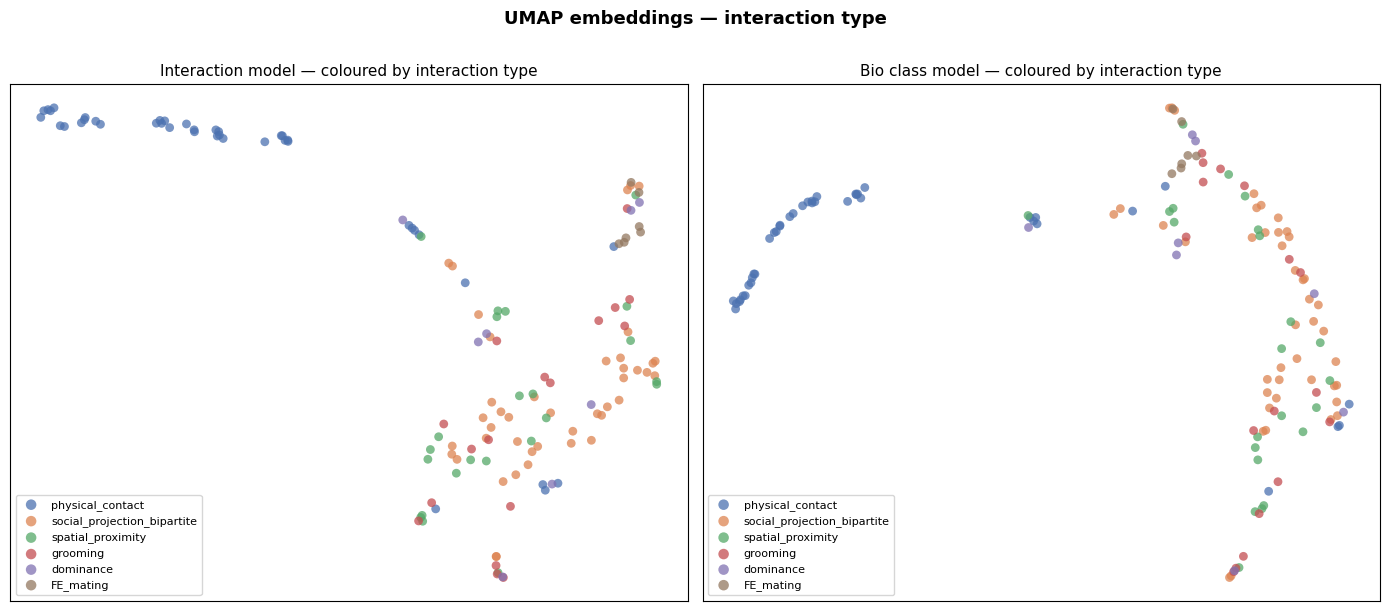

In [ ]:
import matplotlib.pyplot as plt


INT_PALETTE = ['#4C72B0','#DD8452','#55A868','#C44E52','#8172B2','#937860']

BIO_PALETTE = ['#E07B2A','#2E8B57','#4169E1']

def scatter_by_label(ax, coords, labels, names, palette, title):
    for i, name in enumerate(names):
        mask = labels == i
        ax.scatter(coords[mask, 0], coords[mask, 1],
                   label=name, color=palette[i % len(palette)],
                   alpha=0.75, s=40, edgecolors='none')
    ax.set_title(title, fontsize=11)
    ax.set_xticks([]); ax.set_yticks([])
    ax.legend(fontsize=8, markerscale=1.2, loc='best')

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

scatter_by_label(axes[0], coords_int, int_true, selected_interactions,
                 INT_PALETTE, 'Interaction model — coloured by interaction type')
scatter_by_label(axes[1], coords_bio, bio_int,  selected_interactions,
                 INT_PALETTE, 'Bio class model — coloured by interaction type')

plt.suptitle('UMAP embeddings — interaction type', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('umap_by_interaction.pdf', bbox_inches='tight')
plt.show()


## UMAP colored by biological class



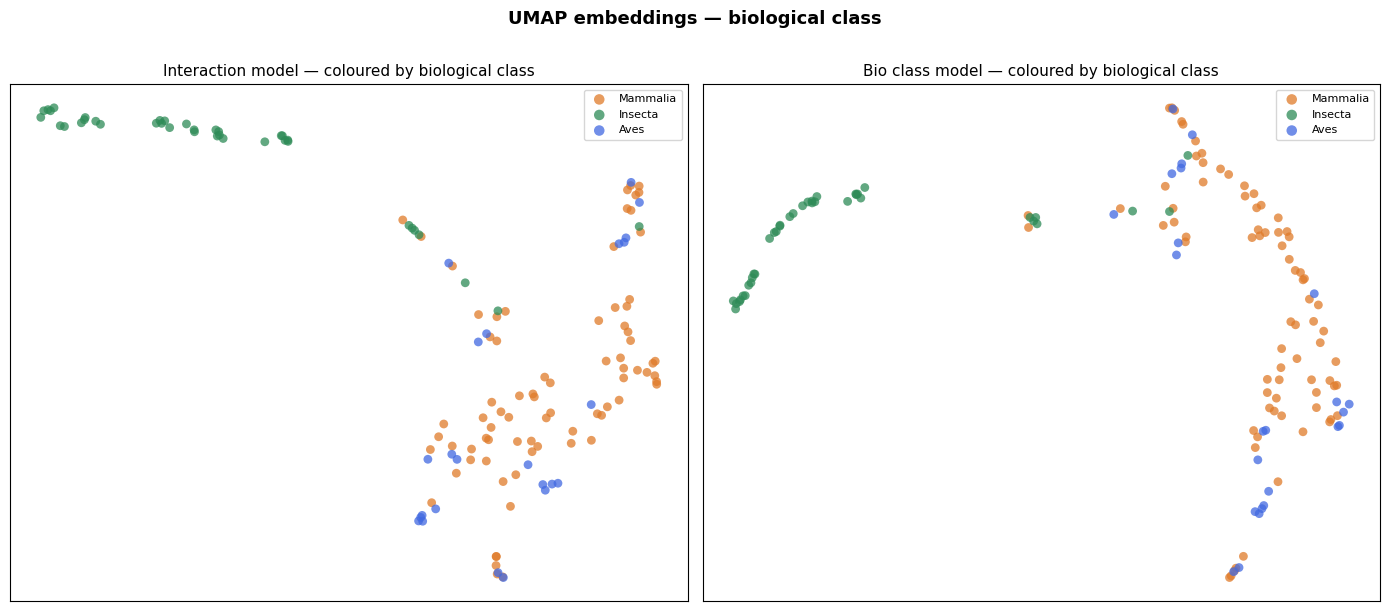

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

scatter_by_label(axes[0], coords_int, int_bio,  bio_names,
                 BIO_PALETTE, 'Interaction model — coloured by biological class')
scatter_by_label(axes[1], coords_bio, bio_true, bio_names,
                 BIO_PALETTE, 'Bio class model — coloured by biological class')

plt.suptitle('UMAP embeddings — biological class', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('umap_by_bio_class.pdf', bbox_inches='tight')
plt.show()


##  Combined: class x interaction type x misclassification



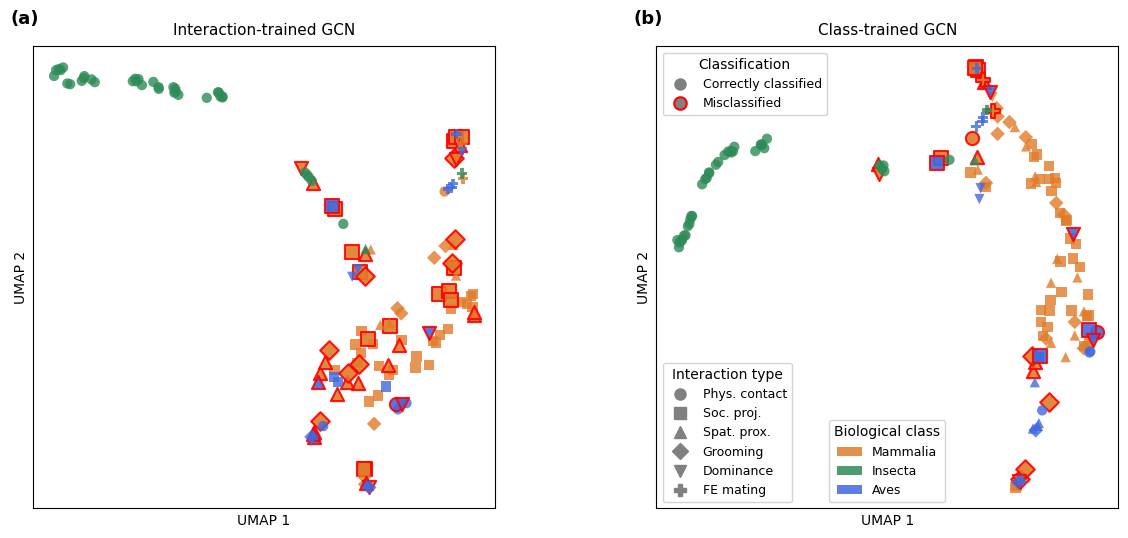

In [ ]:
# Marker shapes 
INT_MARKERS = ['o', 's', '^', 'D', 'v', 'P']

INT_SHORT_LABELS = {
    'physical_contact':            'Phys.\ncontact',
    'social_projection_bipartite': 'Soc.\nproj.',
    'spatial_proximity':           'Spat.\nprox.',
    'grooming':                    'Grooming',
    'dominance':                   'Dominance',
    'FE_mating':                   'FE\nmating',
}

def scatter_class_by_interaction(ax, coords, bio_labels, int_labels,
                                  model_preds, model_true, panel_label,
                                  title):
    """
    Scatter plot where:
      colour  = biological class
      shape   = interaction type
      outline = red if misclassified by the given model, none otherwise
    """
    correct_mask = model_preds == model_true

    for b_idx, bio_name in enumerate(bio_names):
        for i_idx, (int_name, marker) in enumerate(
                zip(selected_interactions, INT_MARKERS)):

            mask_correct = (
                (bio_labels == b_idx) &
                (int_labels == i_idx) &
                correct_mask
            )
            mask_wrong = (
                (bio_labels == b_idx) &
                (int_labels == i_idx) &
                ~correct_mask
            )

            # Correctly classified — no outline
            if mask_correct.sum() > 0:
                ax.scatter(
                    coords[mask_correct, 0], coords[mask_correct, 1],
                    color=BIO_PALETTE[b_idx], marker=marker,
                    s=55, alpha=0.80, edgecolors='none',
                    label=f'{bio_name} / {int_name}'
                          if (b_idx == 0 and i_idx == 0) else None,
                )

            # Misclassified — red outline
            if mask_wrong.sum() > 0:
                ax.scatter(
                    coords[mask_wrong, 0], coords[mask_wrong, 1],
                    color=BIO_PALETTE[b_idx], marker=marker,
                    s=90, alpha=0.90,
                    edgecolors='red', linewidths=1.5,
                )

    ax.set_xticks([]); ax.set_yticks([])
    ax.set_xlabel('UMAP 1', fontsize=10, labelpad=4)
    ax.set_ylabel('UMAP 2', fontsize=10, labelpad=4)
    ax.set_title(title, fontsize=11, pad=8)
    ax.text(-0.05, 1.04, panel_label, transform=ax.transAxes,
            fontsize=13, fontweight='bold', va='bottom')


fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.subplots_adjust(wspace=0.35)

scatter_class_by_interaction(
    axes[0],
    coords=coords_int,
    bio_labels=int_bio,
    int_labels=int_true,
    model_preds=int_pred,
    model_true=int_true,
    panel_label='(a)',
    title='Interaction-trained GCN',
)

scatter_class_by_interaction(
    axes[1],
    coords=coords_bio,
    bio_labels=bio_true,
    int_labels=bio_int,
    model_preds=bio_pred,
    model_true=bio_true,
    panel_label='(b)',
    title='Class-trained GCN',
)

from matplotlib.lines import Line2D
from matplotlib.patches import Patch

bio_handles = [
    Patch(facecolor=BIO_PALETTE[i], label=name, alpha=0.85)
    for i, name in enumerate(bio_names)
]
int_handles = [
    Line2D([0], [0], marker=INT_MARKERS[i], color='grey',
           linestyle='none', markersize=8,
           label=INT_SHORT_LABELS[t].replace('\n', ' '))
    for i, t in enumerate(selected_interactions)
]
err_handles = [
    Line2D([0], [0], marker='o', color='grey', linestyle='none',
           markersize=9, markeredgecolor='none',
           label='Correctly classified'),
    Line2D([0], [0], marker='o', color='grey', linestyle='none',
           markersize=9, markeredgecolor='red', markeredgewidth=1.5,
           label='Misclassified'),
]

leg1 = axes[1].legend(handles=bio_handles, title='Biological class',
                      fontsize=9, title_fontsize=10,
                      loc='lower center', framealpha=0.85)
leg2 = axes[1].legend(handles=int_handles, title='Interaction type',
                      fontsize=9, title_fontsize=10,
                      loc='lower left', framealpha=0.85)
leg3 = axes[1].legend(handles=err_handles, title='Classification',
                      fontsize=9, title_fontsize=10,
                      loc='upper left', framealpha=0.85)

axes[1].add_artist(leg1)
axes[1].add_artist(leg2)

plt.savefig('umap_bio_class_interaction.pdf', bbox_inches='tight', dpi=300)
plt.show()

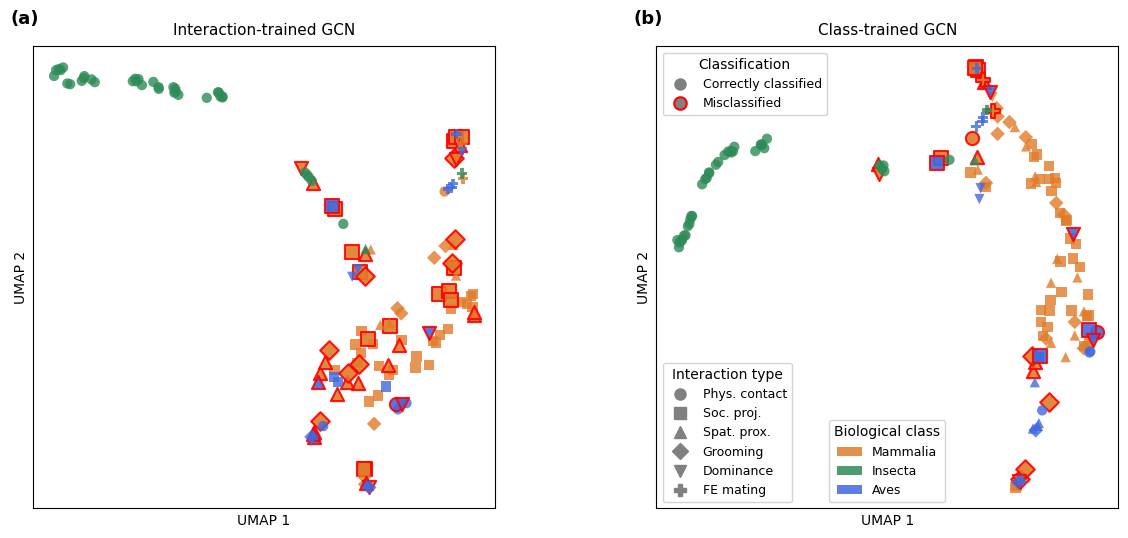

In [ ]:
# Marker shapes
INT_MARKERS = ['o', 's', '^', 'D', 'v', 'P']

INT_SHORT_LABELS = {
    'physical_contact':            'Phys.\ncontact',
    'social_projection_bipartite': 'Soc.\nproj.',
    'spatial_proximity':           'Spat.\nprox.',
    'grooming':                    'Grooming',
    'dominance':                   'Dominance',
    'FE_mating':                   'FE\nmating',
}

def scatter_class_by_interaction(ax, coords, bio_labels, int_labels,
                                  model_preds, model_true, panel_label,
                                  title):
    """
    Scatter plot where:
      colour  = biological class
      shape   = interaction type
      outline = red if misclassified by the given model, none otherwise
    """
    correct_mask = model_preds == model_true

    for b_idx, bio_name in enumerate(bio_names):
        for i_idx, (int_name, marker) in enumerate(
                zip(selected_interactions, INT_MARKERS)):

            mask_correct = (
                (bio_labels == b_idx) &
                (int_labels == i_idx) &
                correct_mask
            )
            mask_wrong = (
                (bio_labels == b_idx) &
                (int_labels == i_idx) &
                ~correct_mask
            )

            # Correctly classified — no outline
            if mask_correct.sum() > 0:
                ax.scatter(
                    coords[mask_correct, 0], coords[mask_correct, 1],
                    color=BIO_PALETTE[b_idx], marker=marker,
                    s=55, alpha=0.80, edgecolors='none',
                    label=f'{bio_name} / {int_name}'
                          if (b_idx == 0 and i_idx == 0) else None,
                )

            # Misclassified — red outline
            if mask_wrong.sum() > 0:
                ax.scatter(
                    coords[mask_wrong, 0], coords[mask_wrong, 1],
                    color=BIO_PALETTE[b_idx], marker=marker,
                    s=90, alpha=0.90,
                    edgecolors='red', linewidths=1.5,
                )

    ax.set_xticks([]); ax.set_yticks([])
    ax.set_xlabel('UMAP 1', fontsize=10, labelpad=4)
    ax.set_ylabel('UMAP 2', fontsize=10, labelpad=4)
    ax.set_title(title, fontsize=11, pad=8)
    ax.text(-0.05, 1.04, panel_label, transform=ax.transAxes,
            fontsize=13, fontweight='bold', va='bottom')


fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.subplots_adjust(wspace=0.35)

scatter_class_by_interaction(
    axes[0],
    coords=coords_int,
    bio_labels=int_bio,
    int_labels=int_true,
    model_preds=int_pred,
    model_true=int_true,
    panel_label='(a)',
    title='Interaction-trained GCN',
)

scatter_class_by_interaction(
    axes[1],
    coords=coords_bio,
    bio_labels=bio_true,
    int_labels=bio_int,
    model_preds=bio_pred,
    model_true=bio_true,
    panel_label='(b)',
    title='Class-trained GCN',
)

from matplotlib.lines import Line2D
from matplotlib.patches import Patch

bio_handles = [
    Patch(facecolor=BIO_PALETTE[i], label=name, alpha=0.85)
    for i, name in enumerate(bio_names)
]
int_handles = [
    Line2D([0], [0], marker=INT_MARKERS[i], color='grey',
           linestyle='none', markersize=8,
           label=INT_SHORT_LABELS[t].replace('\n', ' '))
    for i, t in enumerate(selected_interactions)
]
err_handles = [
    Line2D([0], [0], marker='o', color='grey', linestyle='none',
           markersize=9, markeredgecolor='none',
           label='Correctly classified'),
    Line2D([0], [0], marker='o', color='grey', linestyle='none',
           markersize=9, markeredgecolor='red', markeredgewidth=1.5,
           label='Misclassified'),
]

leg1 = axes[1].legend(handles=bio_handles, title='Biological class',
                      fontsize=9, title_fontsize=10,
                      loc='lower center', framealpha=0.85)
leg2 = axes[1].legend(handles=int_handles, title='Interaction type',
                      fontsize=9, title_fontsize=10,
                      loc='lower left', framealpha=0.85)
leg3 = axes[1].legend(handles=err_handles, title='Classification',
                      fontsize=9, title_fontsize=10,
                      loc='upper left', framealpha=0.85)

axes[1].add_artist(leg1)
axes[1].add_artist(leg2)

plt.savefig('umap_bio_class_interaction.pdf', bbox_inches='tight', dpi=300)
plt.show()